# Per level analysis

Saved heatmaps/level_2/heatmap_initiate_collaboration.png
Saved heatmaps/level_2/heatmap_mean_f1_agent_0.png
Saved heatmaps/level_2/heatmap_mean_f1_agent_1.png
Saved heatmaps/level_2/heatmap_mean_redundancy_agent_0.png
Saved heatmaps/level_2/heatmap_mean_redundancy_agent_1.png
Saved heatmaps/level_2/heatmap_mean_similarity_agent_0.png
Saved heatmaps/level_2/heatmap_mean_similarity_agent_1.png
Saved heatmaps/level_2/heatmap_overall_collaboration.png
Saved heatmaps/level_2/heatmap_respond_collaboration.png
Saved heatmaps/level_2/heatmap_std_f1_agent_0.png
Saved heatmaps/level_2/heatmap_std_f1_agent_1.png
Saved heatmaps/level_2/heatmap_std_redundancy_agent_0.png
Saved heatmaps/level_2/heatmap_std_redundancy_agent_1.png
Saved heatmaps/level_2/heatmap_std_similarity_agent_0.png
Saved heatmaps/level_2/heatmap_std_similarity_agent_1.png
Saved heatmaps/level_2/heatmap_success_rate.png


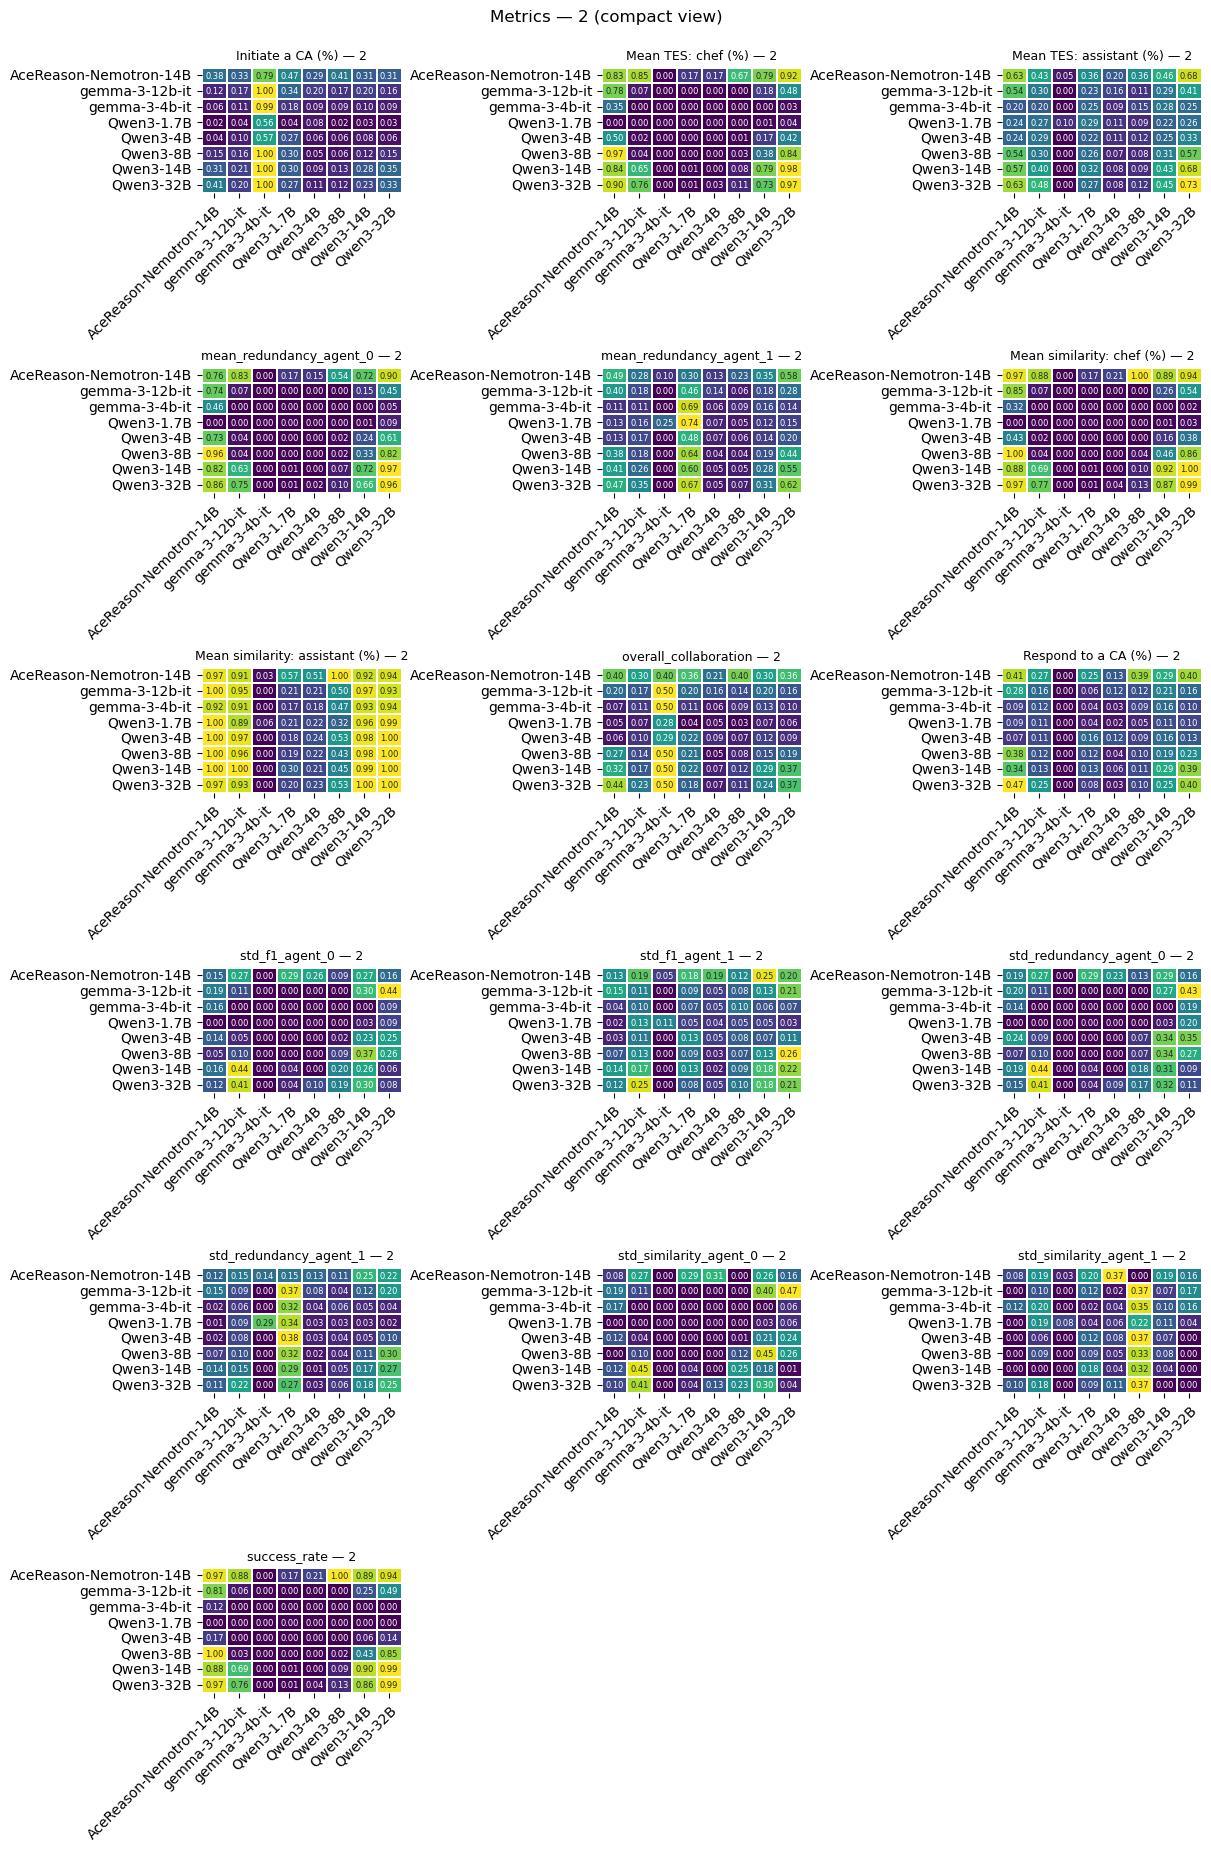

Saved heatmaps/all_levels/heatmap_initiate_collaboration.png
Saved heatmaps/all_levels/heatmap_mean_f1_agent_0.png
Saved heatmaps/all_levels/heatmap_mean_f1_agent_1.png
Saved heatmaps/all_levels/heatmap_mean_redundancy_agent_0.png
Saved heatmaps/all_levels/heatmap_mean_redundancy_agent_1.png
Saved heatmaps/all_levels/heatmap_mean_similarity_agent_0.png
Saved heatmaps/all_levels/heatmap_mean_similarity_agent_1.png
Saved heatmaps/all_levels/heatmap_overall_collaboration.png
Saved heatmaps/all_levels/heatmap_respond_collaboration.png
Saved heatmaps/all_levels/heatmap_std_f1_agent_0.png
Saved heatmaps/all_levels/heatmap_std_f1_agent_1.png
Saved heatmaps/all_levels/heatmap_std_redundancy_agent_0.png
Saved heatmaps/all_levels/heatmap_std_redundancy_agent_1.png
Saved heatmaps/all_levels/heatmap_std_similarity_agent_0.png
Saved heatmaps/all_levels/heatmap_std_similarity_agent_1.png
Saved heatmaps/all_levels/heatmap_success_rate.png


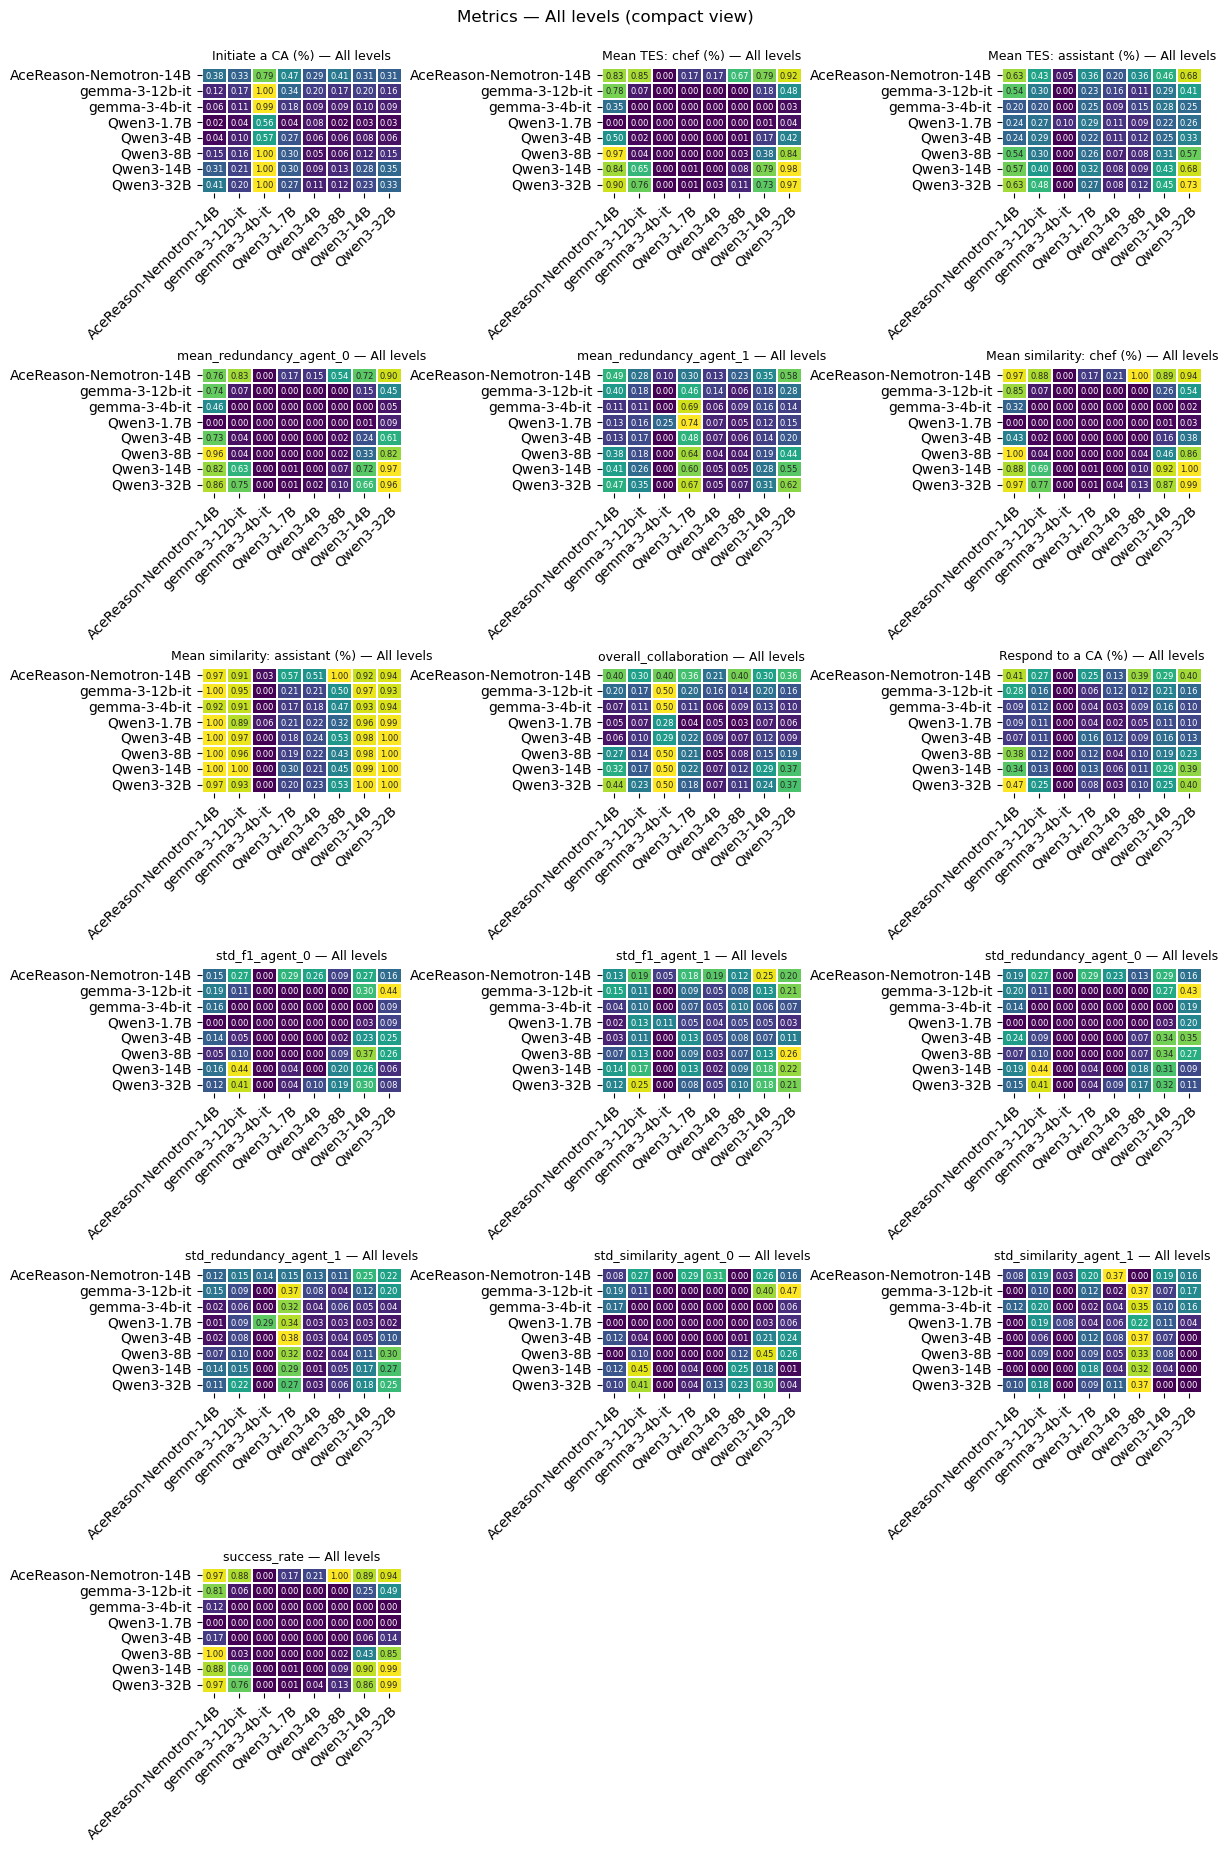

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Generate annotated heat-maps for every numeric metric in the input CSV.
Adds level-aware reporting:
  • Per-level heat-maps (each level separately)
  • Optional "all levels" aggregate, with configurable aggregation function
Saves PNGs and shows compact inline grids in a Jupyter notebook.

Updated: 2025-08-11 — level-aware aggregation
  • LEVEL_MODE: "each" | "all" | "each_and_all"
  • LEVELS_TO_INCLUDE: None (auto) or explicit list
  • Aggregation function for "all levels" is configurable (default: mean)
  • Folder structure: heatmaps/<level_slug>/...

Retains earlier changes (2025-07-09):
  • Centralised heat-map kwargs for PNG/inline parity
  • Suppressed colour-bars; compact 4×3 panels
  • Unicode U+2011 → ASCII "-" normalization to avoid glyph warnings
  • Identical titles for PNG and inline
"""

import math
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ───────────────────────────────────────────────────────────────
# 0. User-configurable labels  (edit below as needed)
# ───────────────────────────────────────────────────────────────
# Pretty names for models that will appear on axes ticks.
# Keys must match raw entries found in agent0_model / agent1_model
model_labels: dict[str, str] = {
    "Qwen2.5-14B-Instruct": "Qwen2.5-14B",
    "Qwen2.5-32B-Instruct": "Qwen2.5-32B",
    "Qwen2.5-7B-Instruct" : "Qwen2.5-07B",
    "Mistral-7B-Instruct-v0.1": "Mistral-07B",
    "Meta-Llama-3-8B-Instruct": "Llama3-08B",
}

# Normalise dictionary keys (replace non-breaking hyphen with standard hyphen)
model_labels = {k.replace("\u2011", "-"): v for k, v in model_labels.items()}

# Pretty names for metric labels and colour-bar.
metric_labels: dict[str, str] = {
    "mean_similarity_agent_0": "Mean similarity: chef (%)",
    "mean_similarity_agent_1": "Mean similarity: assistant (%)",
    "mean_f1_agent_0": "Mean TES: chef (%)",
    "mean_f1_agent_1": "Mean TES: assistant (%)",
    "initiate_collaboration": "Initiate a CA (%)",
    "respond_collaboration": "Respond to a CA (%)",
}

# Optional: human-friendly names for levels, e.g. {0: "Easy", 1: "Med", 2: "Hard"}
level_labels: dict = {}  # leave empty to use the raw level values

# Axis labels (set to blank to mirror inline view)
x_axis_label: str = ""
y_axis_label: str = ""
# Title template mirrors inline/PNG parity.
# Use {metric_label} and {level_label} tokens; for "all levels" we inject "All levels".
title_template: str = "{metric_label} — {level_label}"

# ───────────────────────────────────────────────────────────────
# 0-bis. Centralised heat-map styling — **single source of truth**
# ───────────────────────────────────────────────────────────────
HEATMAP_KWARGS: dict = dict(
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},     # small font, identical online/offline
    cmap="viridis",            # same colour map everywhere
    linewidths=0.25,
    linecolor="white",
    cbar=False,                # suppress colour-bar as in notebook view
)

# ───────────────────────────────────────────────────────────────
# 0-ter. Level reporting controls
# ───────────────────────────────────────────────────────────────
# Choose: "each" (per-level only), "all" (aggregate only), "each_and_all" (both)
LEVEL_MODE: str = "each_and_all"

# Explicit subset of levels to include, or None to auto-discover
LEVELS_TO_INCLUDE: Optional[Iterable] = None

# Aggregation function for "all levels"
AGG_FUN = "mean"  # "mean", "median", "max", "min", or any pandas reducer name

# Composite grid layout (inline)
N_COLS_COMPOSITE: int = 3

# ───────────────────────────────────────────────────────────────
# 1. Load and pre-process
# ───────────────────────────────────────────────────────────────
# IMPORTANT: point this to your uploaded CSV file
csv_path = "converted_data_cross-play-data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Split the composite model column → agent0_model / agent1_model
# Assumes "model" looks like "..._<agent0>_VS_<agent1>_..."
parts = df["model"].str.split("_", expand=True)
df["agent0_model"] = parts[1]
df["agent1_model"] = parts[3]

# Replace any non-breaking hyphens (U+2011) with the standard hyphen-minus
for col in ("agent0_model", "agent1_model"):
    df[col] = df[col].str.replace("\u2011", "-", regex=False)

# Identify all numeric metrics (drop clearly non-metric timing columns)
numeric_cols = (
    df.select_dtypes(include="number")
      .columns.difference(["level", "steps", "time_avg", "time_var"])
      .tolist()
)

# Decide which levels we will include
if LEVELS_TO_INCLUDE is None:
    # Use the order of appearance (stable) for consistent panel ordering
    levels_in_data = list(pd.unique(df["level"]))
else:
    levels_in_data = list(LEVELS_TO_INCLUDE)

# Helper to pretty-print level values
def _level_name(val):
    if val == "__ALL__":
        return "All levels"
    return level_labels.get(val, str(val))

# ───────────────────────────────────────────────────────────────
# 2. Group once at the most granular level we care about
#    Mean over duplicate rows within (agent0, agent1, level)
# ───────────────────────────────────────────────────────────────
group_cols = ["agent0_model", "agent1_model", "level"]
df_mean = (
    df.groupby(group_cols, dropna=False)[numeric_cols]
      .mean()
      .reset_index()
)

# Build a list of "reporting scopes": each level, plus optionally an "__ALL__" aggregate
report_scopes = []
if LEVEL_MODE in ("each", "each_and_all"):
    report_scopes.extend(levels_in_data)
if LEVEL_MODE in ("all", "each_and_all"):
    report_scopes.append("__ALL__")

# ───────────────────────────────────────────────────────────────
# 3. Rendering utilities
# ───────────────────────────────────────────────────────────────

## All of the code in this block is meant to alphabetically sort models names ##
import re

# If you mix families (e.g., Qwen3, Llama3), set this True to sort "within family"
ORDER_WITHIN_FAMILY = True

_SCALE = {"K": 1e-3, "M": 1e-6, "B": 1.0, "T": 1e3}

def _size_sort_key(label: str):
    s = str(label)
    # Split once at the last '-' so "Qwen3-14B" → ("Qwen3", "14B")
    if "-" in s:
        family, tail = s.rsplit("-", 1)
    else:
        family, tail = s, s
    # Parse something like "14B", "1.7B", "07B"
    m = re.search(r"(\d+(?:\.\d+)?)[ ]*([KMBT])\b", tail, flags=re.I)
    if m:
        num = float(m.group(1))
        unit = m.group(2).upper()
        size_b = num * _SCALE.get(unit, 1.0)  # normalize to “billions”
    else:
        size_b = float("inf")  # unparseable labels go to the end

    if ORDER_WITHIN_FAMILY:
        return (family.casefold(), size_b, s.casefold())
    else:
        # Pure size ordering across all families
        return (size_b, family.casefold(), s.casefold())
## All of the code in this block is meant to alphabetically sort models names ##

def _pivot_for_scope(metric: str, scope):
    """
    Return a pivot (rows=agent0, cols=agent1) for a given metric and scope (level or "__ALL__").
    Applies model label prettification and sorts axes.
    """
    if scope == "__ALL__":
        # Aggregate across levels first
        agg = (
            df_mean.groupby(["agent0_model", "agent1_model"], dropna=False)[metric]
                  .agg(AGG_FUN)
                  .reset_index()
        )
    else:
        # Filter for the specific level
        agg = df_mean[df_mean["level"] == scope][["agent0_model", "agent1_model", metric]]

    pivot = (
        agg.groupby(["agent0_model", "agent1_model"])[metric]
           .mean()
           .unstack(fill_value=np.nan)
    )

    pivot = pivot.rename(index=model_labels, columns=model_labels)
    
    # Sort axes by numeric model size (then by family for ties if enabled)
    row_order = sorted(pivot.index, key=_size_sort_key)
    col_order = sorted(pivot.columns, key=_size_sort_key)
    pivot = pivot.reindex(index=row_order, columns=col_order)
    return pivot

def _save_and_collect(pivots_for_scope: dict, scope, out_root: Path):
    """
    Save individual PNGs for a scope to heatmaps/<level_slug>/..., and return a list of (metric_label, pivot).
    """
    level_slug = "all_levels" if scope == "__ALL__" else f"level_{_level_name(scope)}".replace(" ", "_")
    out_dir = out_root / level_slug
    out_dir.mkdir(parents=True, exist_ok=True)

    collected = []
    for metric in numeric_cols:
        pivot = _pivot_for_scope(metric, scope)
        metric_label = metric_labels.get(metric, metric)

        # Store for composite grid
        collected.append((metric_label, pivot))

        # Individual PNG (match inline look)
        fig, ax = plt.subplots(figsize=(4, 3))
        sns.heatmap(pivot, **HEATMAP_KWARGS, ax=ax)

        title = title_template.format(metric_label=metric_label, level_label=_level_name(scope))
        ax.set_title(title, pad=8)
        ax.set_xlabel(x_axis_label)
        ax.set_ylabel(y_axis_label)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        fig.tight_layout()
        outfile = out_dir / f"heatmap_{metric}.png"
        fig.savefig(outfile, dpi=300)
        plt.close(fig)
        print(f"Saved {outfile}")
    return collected, out_dir

def _composite_inline(collected: list, scope):
    """
    Show a compact inline grid for a given scope.
    """
    n = len(collected)
    if n == 0:
        return
    ncols = max(1, N_COLS_COMPOSITE)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4, nrows * 3),
        squeeze=False,
        constrained_layout=True,
    )

    for idx, (metric_label, pivot) in enumerate(collected):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sns.heatmap(pivot, **HEATMAP_KWARGS, ax=ax)
        # Inline titles are the source of truth
        inline_title = title_template.format(metric_label=metric_label, level_label=_level_name(scope))
        ax.set_title(inline_title, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Hide any unused axes
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    fig.suptitle(f"Metrics — {_level_name(scope)} (compact view)", y=1.02, fontsize=12)
    plt.show()

# ───────────────────────────────────────────────────────────────
# 4. Run: save PNGs and show inline grids for each requested scope
# ───────────────────────────────────────────────────────────────
out_root = Path("heatmaps")
out_root.mkdir(exist_ok=True)

for scope in report_scopes:
    try:
        collected, scope_dir = _save_and_collect({}, scope, out_root)
        _composite_inline(collected, scope)
    except Exception as e:
        # Fail quietly outside interactive sessions, but print scope for debugging
        print(f"[WARN] Skipped inline view for scope={_level_name(scope)} due to: {e}")


Saved heatmaps/level_2/heatmap_initiate_collaboration.png
Saved heatmaps/level_2/heatmap_mean_f1_agent_0.png
Saved heatmaps/level_2/heatmap_mean_f1_agent_1.png
Saved heatmaps/level_2/heatmap_mean_redundancy_agent_0.png
Saved heatmaps/level_2/heatmap_mean_redundancy_agent_1.png
Saved heatmaps/level_2/heatmap_mean_similarity_agent_0.png
Saved heatmaps/level_2/heatmap_mean_similarity_agent_1.png
Saved heatmaps/level_2/heatmap_overall_collaboration.png
Saved heatmaps/level_2/heatmap_respond_collaboration.png
Saved heatmaps/level_2/heatmap_std_f1_agent_0.png
Saved heatmaps/level_2/heatmap_std_f1_agent_1.png
Saved heatmaps/level_2/heatmap_std_redundancy_agent_0.png
Saved heatmaps/level_2/heatmap_std_redundancy_agent_1.png
Saved heatmaps/level_2/heatmap_std_similarity_agent_0.png
Saved heatmaps/level_2/heatmap_std_similarity_agent_1.png
Saved heatmaps/level_2/heatmap_success_rate.png


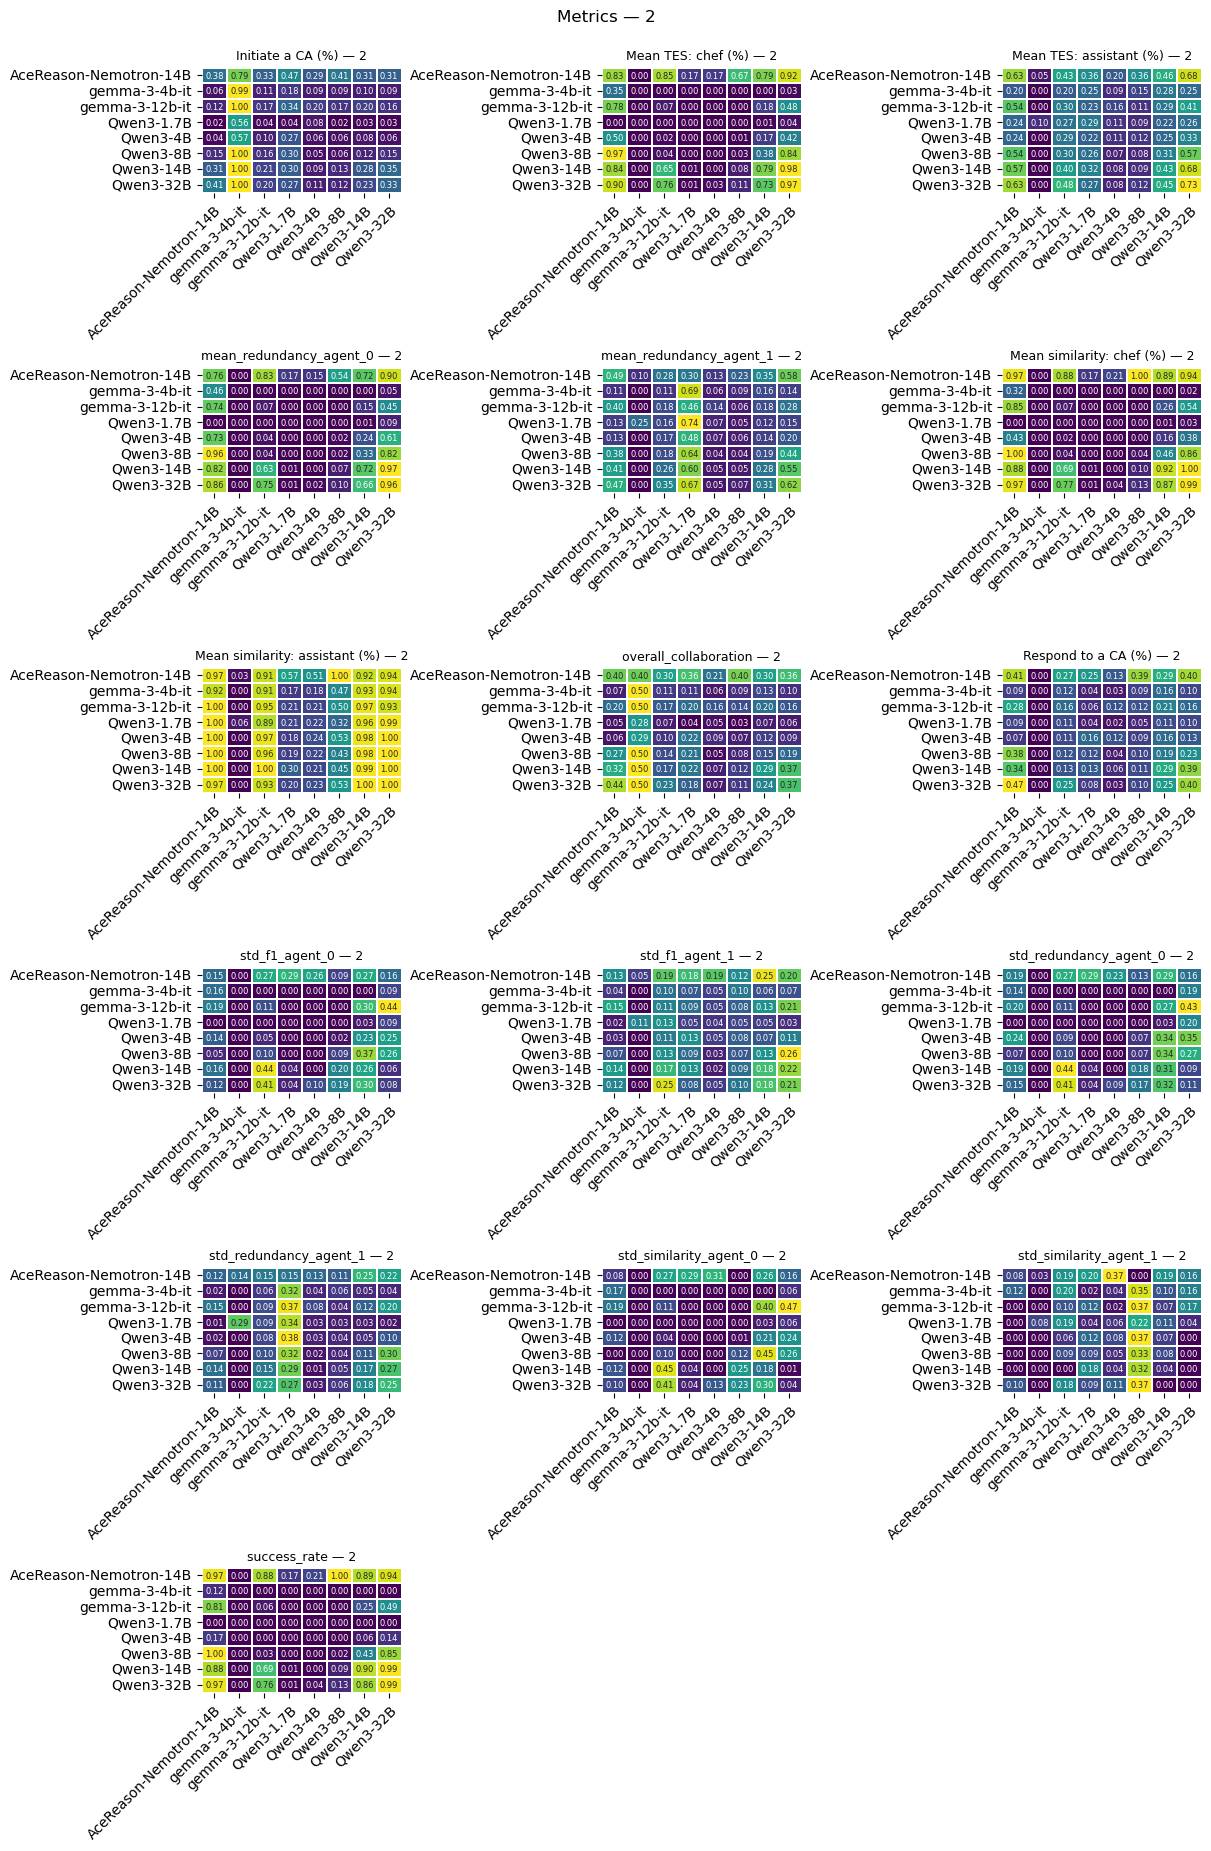

Saved heatmaps/level_2/match_size-4b/heatmap_initiate_collaboration_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_mean_f1_agent_0_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_mean_f1_agent_1_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_mean_redundancy_agent_0_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_mean_redundancy_agent_1_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_mean_similarity_agent_0_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_mean_similarity_agent_1_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_overall_collaboration_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_respond_collaboration_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_std_f1_agent_0_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_std_f1_agent_1_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_std_redundancy_agent_0_size-4b.png
Saved heatmaps/level_2/match_size-4b/heatmap_std_redundancy_agent_1_

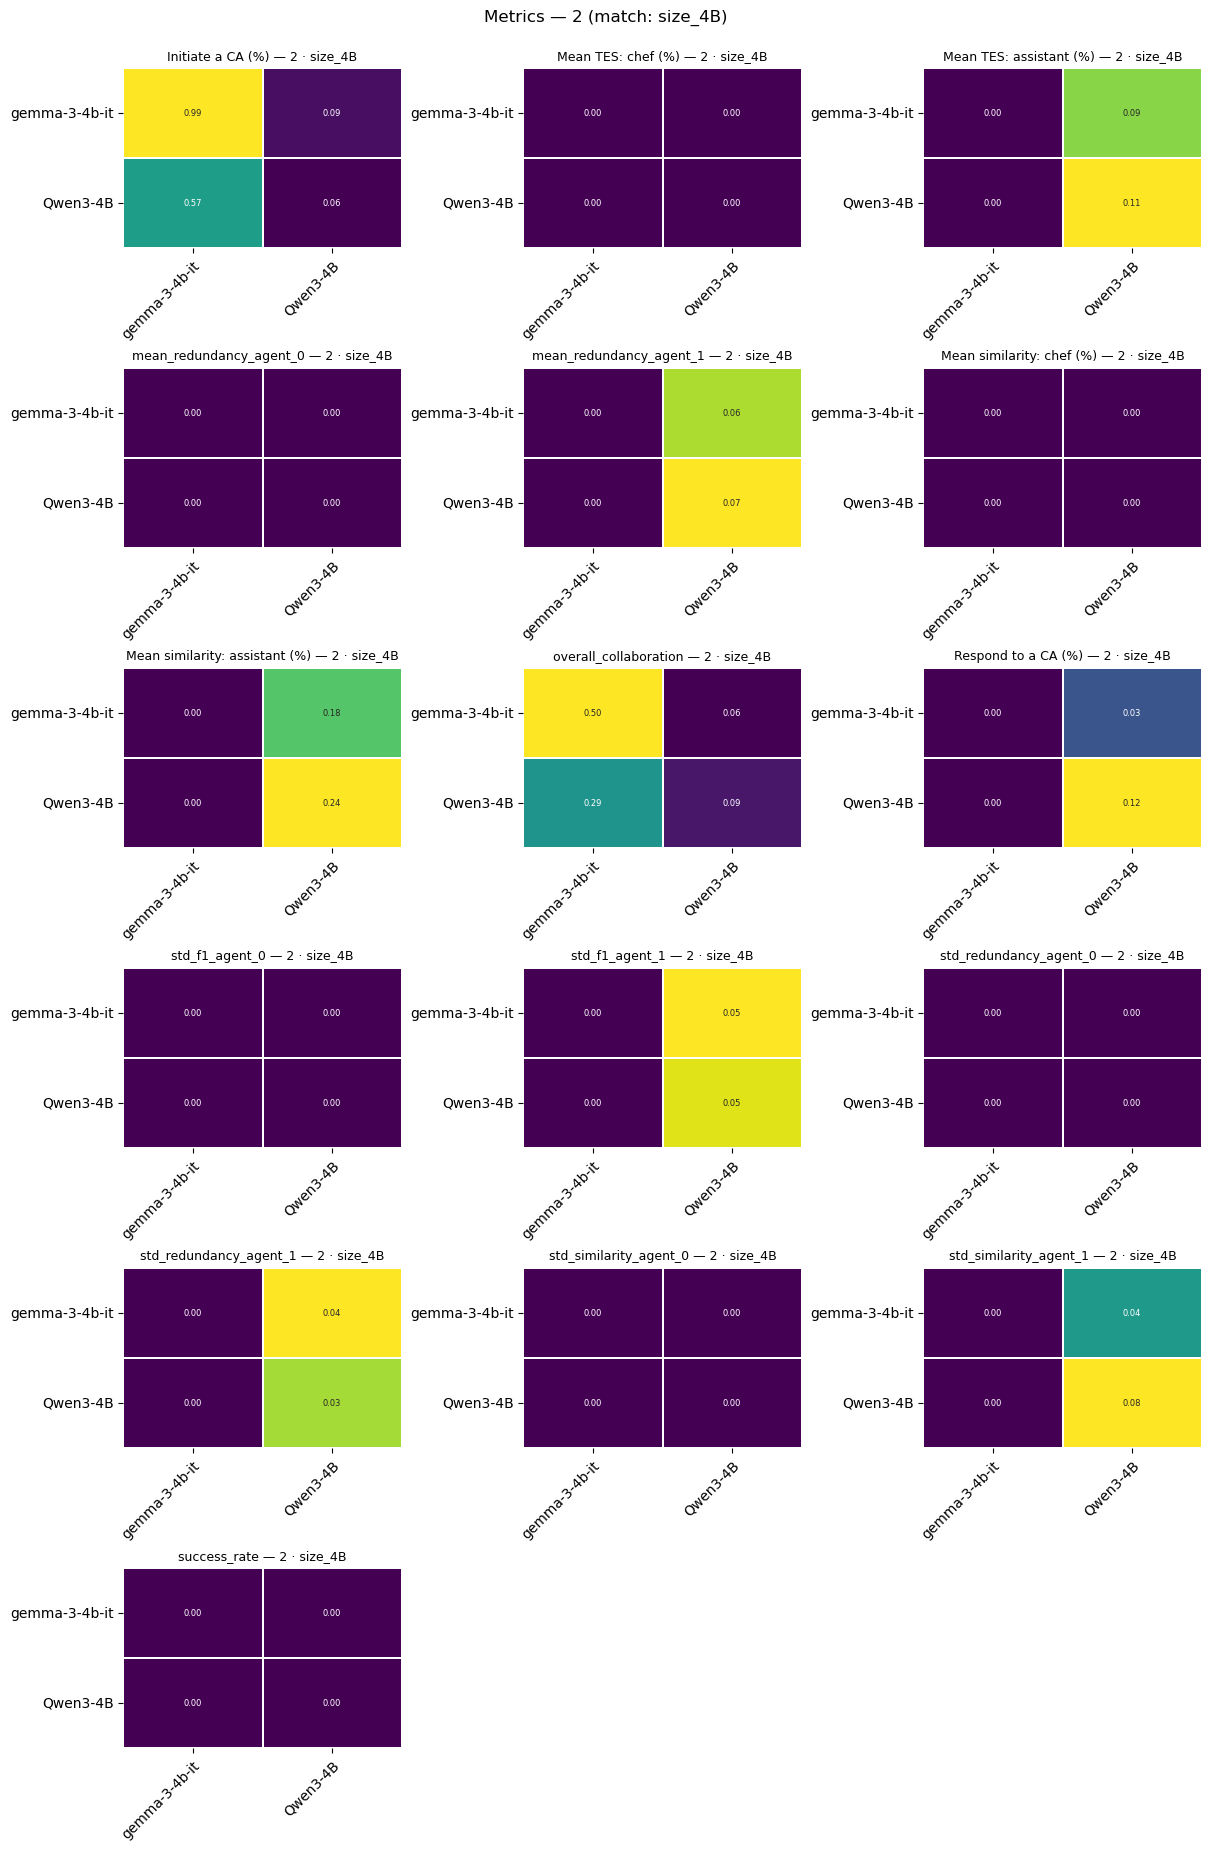

Saved heatmaps/level_2/match_size-14b-12b/heatmap_initiate_collaboration_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_mean_f1_agent_0_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_mean_f1_agent_1_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_mean_redundancy_agent_0_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_mean_redundancy_agent_1_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_mean_similarity_agent_0_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_mean_similarity_agent_1_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_overall_collaboration_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_respond_collaboration_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_std_f1_agent_0_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-12b/heatmap_std_f1_agent_1_size-14b-12b.png
Saved heatmaps/level_2/match_size-14b-

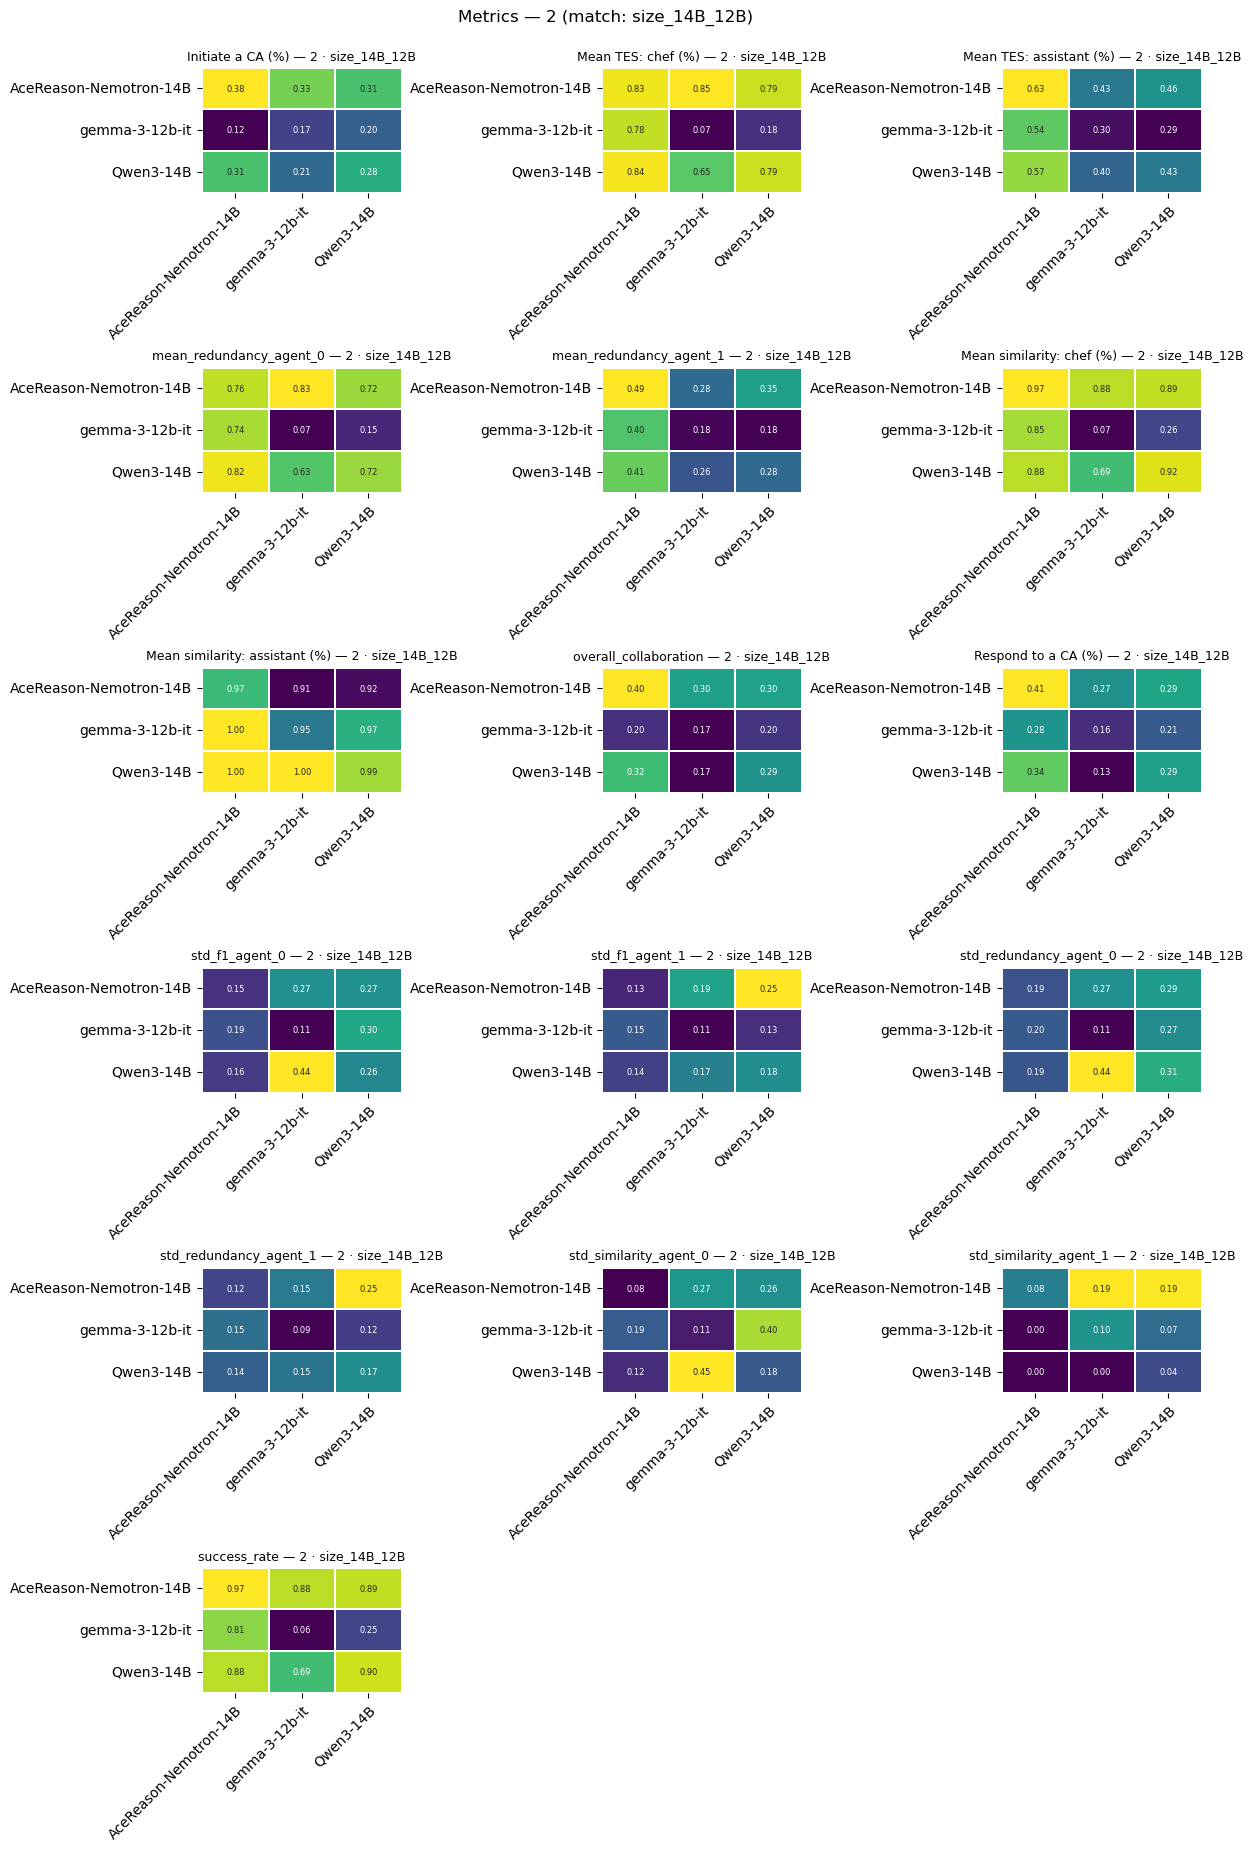

Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_initiate_collaboration_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_mean_f1_agent_0_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_mean_f1_agent_1_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_mean_redundancy_agent_0_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_mean_redundancy_agent_1_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_mean_similarity_agent_0_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_mean_similarity_agent_1_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_overall_collaboration_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_respond_collaboration_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-8-32b/heatmap_std_f1_agent_0_size-14-12-8-32b.png
Saved heatmaps/level_2/match_size-14-12-

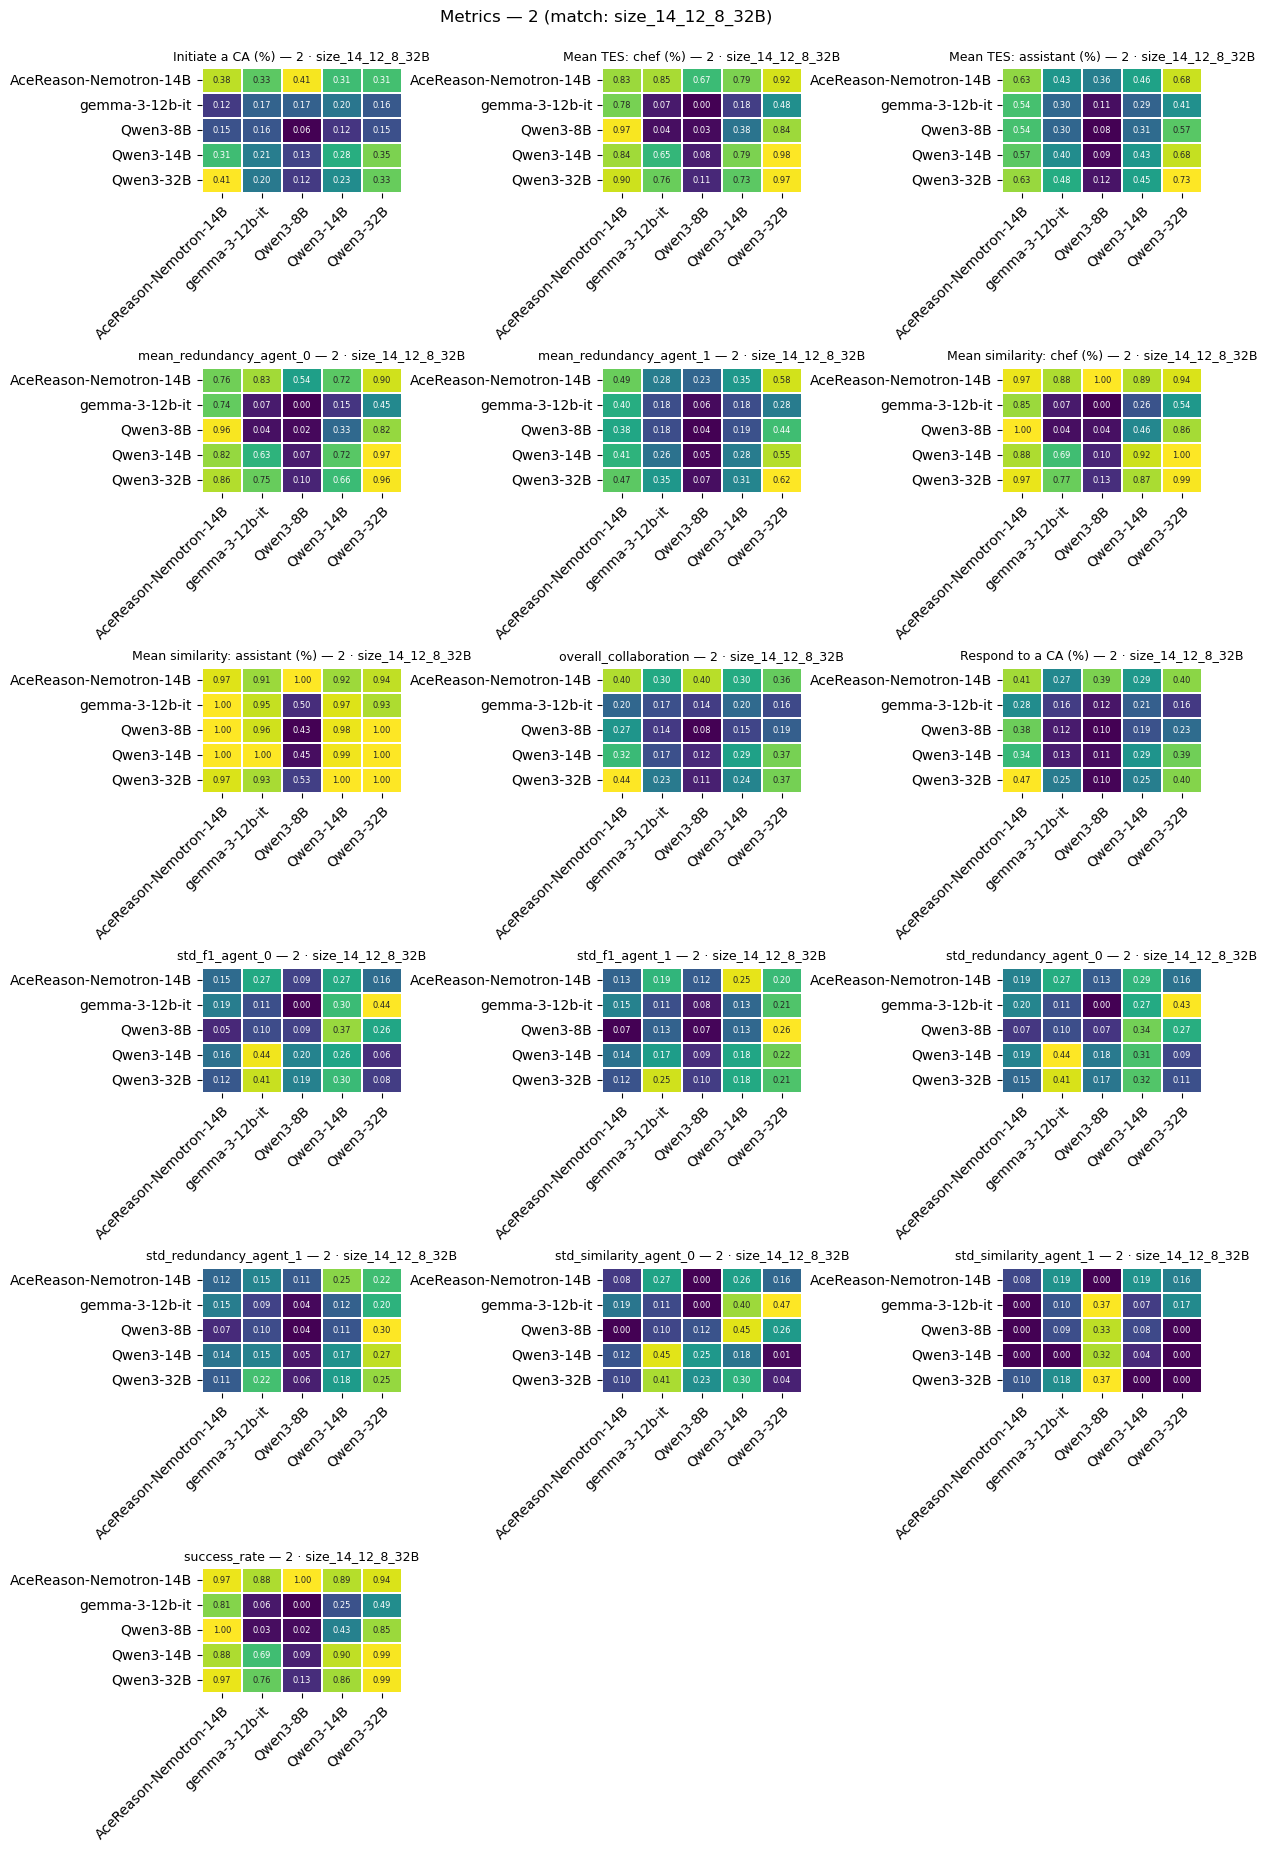

Saved heatmaps/all_levels/heatmap_initiate_collaboration.png
Saved heatmaps/all_levels/heatmap_mean_f1_agent_0.png
Saved heatmaps/all_levels/heatmap_mean_f1_agent_1.png
Saved heatmaps/all_levels/heatmap_mean_redundancy_agent_0.png
Saved heatmaps/all_levels/heatmap_mean_redundancy_agent_1.png
Saved heatmaps/all_levels/heatmap_mean_similarity_agent_0.png
Saved heatmaps/all_levels/heatmap_mean_similarity_agent_1.png
Saved heatmaps/all_levels/heatmap_overall_collaboration.png
Saved heatmaps/all_levels/heatmap_respond_collaboration.png
Saved heatmaps/all_levels/heatmap_std_f1_agent_0.png
Saved heatmaps/all_levels/heatmap_std_f1_agent_1.png
Saved heatmaps/all_levels/heatmap_std_redundancy_agent_0.png
Saved heatmaps/all_levels/heatmap_std_redundancy_agent_1.png
Saved heatmaps/all_levels/heatmap_std_similarity_agent_0.png
Saved heatmaps/all_levels/heatmap_std_similarity_agent_1.png
Saved heatmaps/all_levels/heatmap_success_rate.png


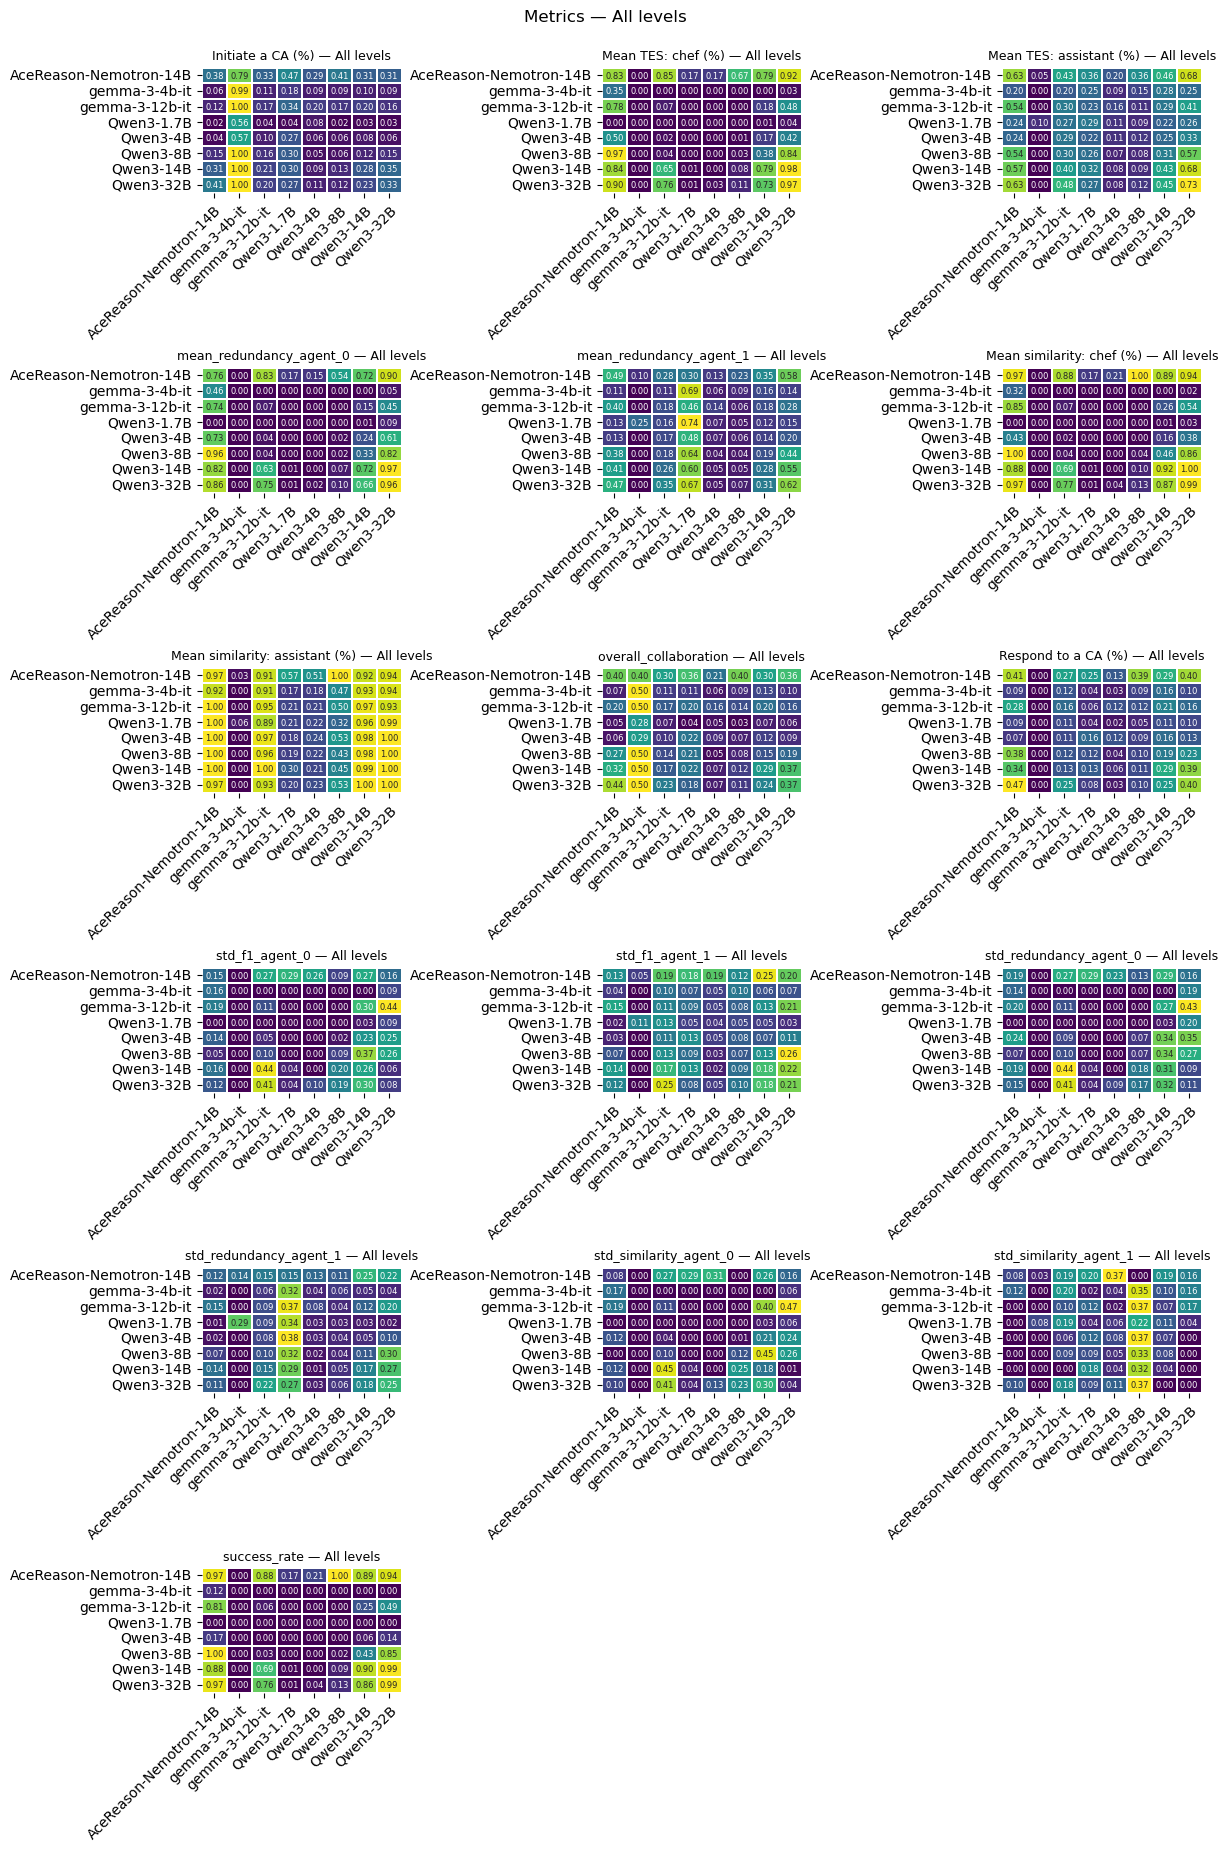

Saved heatmaps/all_levels/match_size-4b/heatmap_initiate_collaboration_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_mean_f1_agent_0_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_mean_f1_agent_1_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_mean_redundancy_agent_0_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_mean_redundancy_agent_1_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_mean_similarity_agent_0_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_mean_similarity_agent_1_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_overall_collaboration_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_respond_collaboration_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_std_f1_agent_0_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_std_f1_agent_1_size-4b.png
Saved heatmaps/all_levels/match_size-4b/heatmap_std_redundancy_agent_0_size-4b.png
Saved heatmaps/all_levels/match_

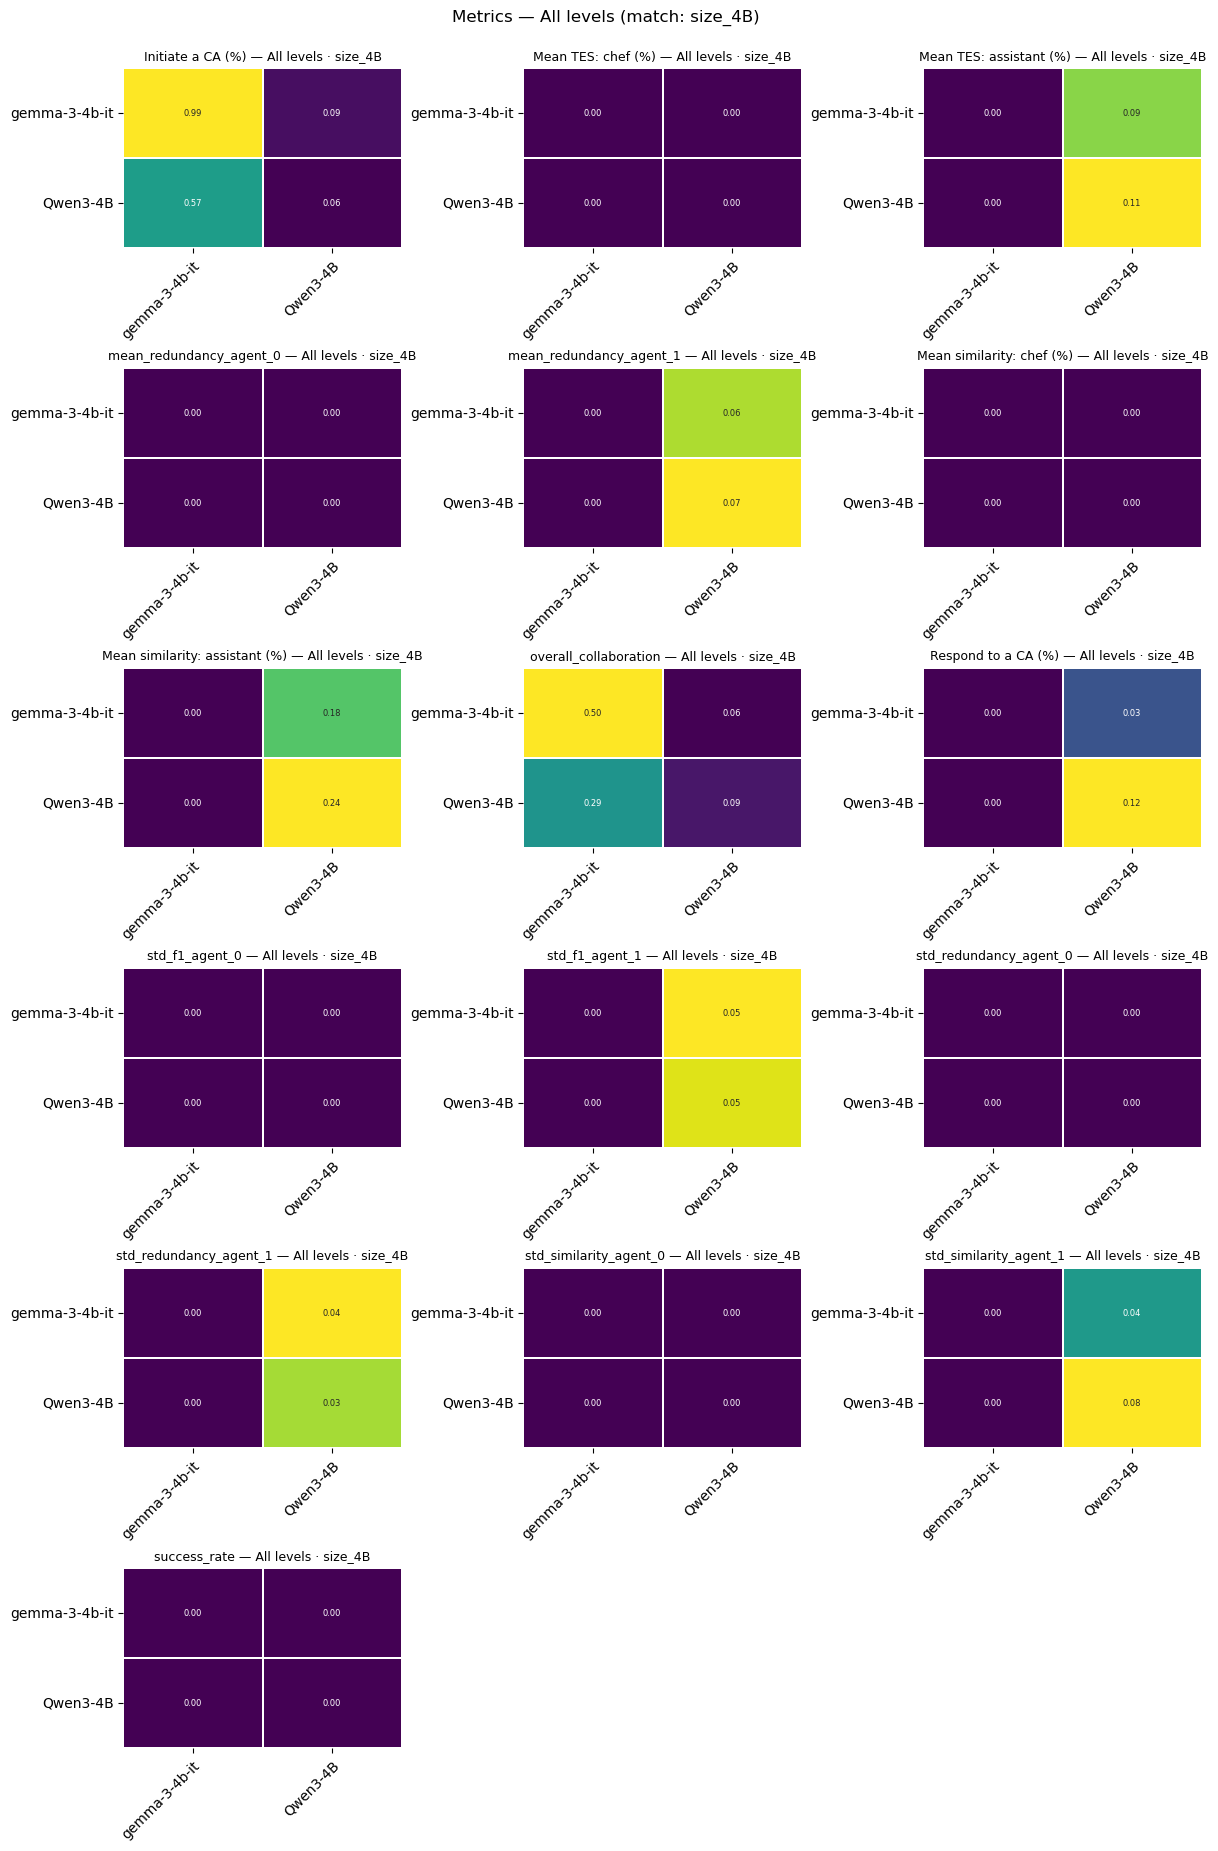

Saved heatmaps/all_levels/match_size-14b-12b/heatmap_initiate_collaboration_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_mean_f1_agent_0_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_mean_f1_agent_1_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_mean_redundancy_agent_0_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_mean_redundancy_agent_1_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_mean_similarity_agent_0_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_mean_similarity_agent_1_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_overall_collaboration_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_respond_collaboration_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_std_f1_agent_0_size-14b-12b.png
Saved heatmaps/all_levels/match_size-14b-12b/heatmap_std_f1_agent_1_size-14b-12b.png
Saved

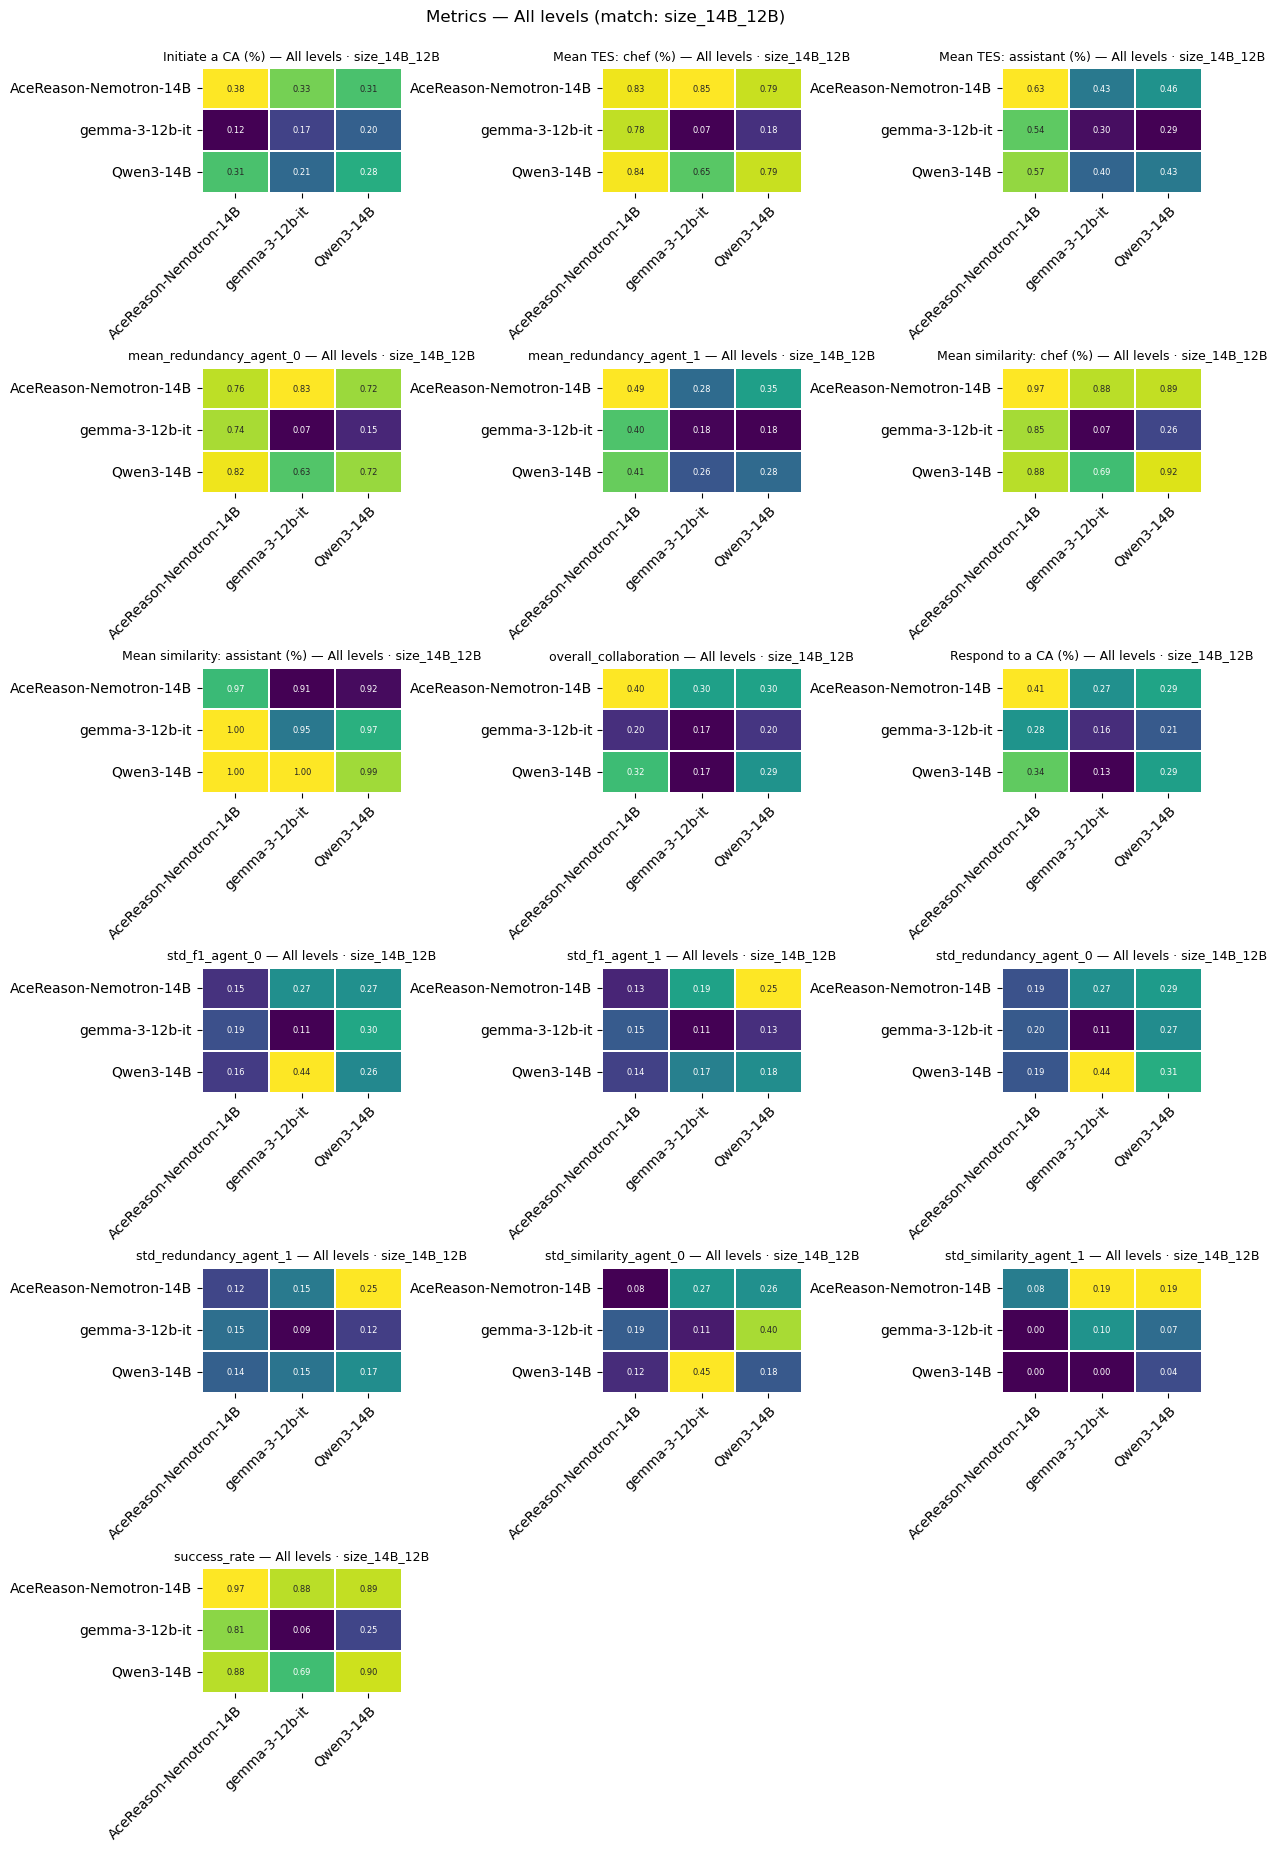

Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_initiate_collaboration_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_mean_f1_agent_0_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_mean_f1_agent_1_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_mean_redundancy_agent_0_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_mean_redundancy_agent_1_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_mean_similarity_agent_0_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_mean_similarity_agent_1_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_overall_collaboration_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_respond_collaboration_size-14-12-8-32b.png
Saved heatmaps/all_levels/match_size-14-12-8-32b/heatmap_std_f1_agent_0_size-14-12-8-32b.png
Saved heat

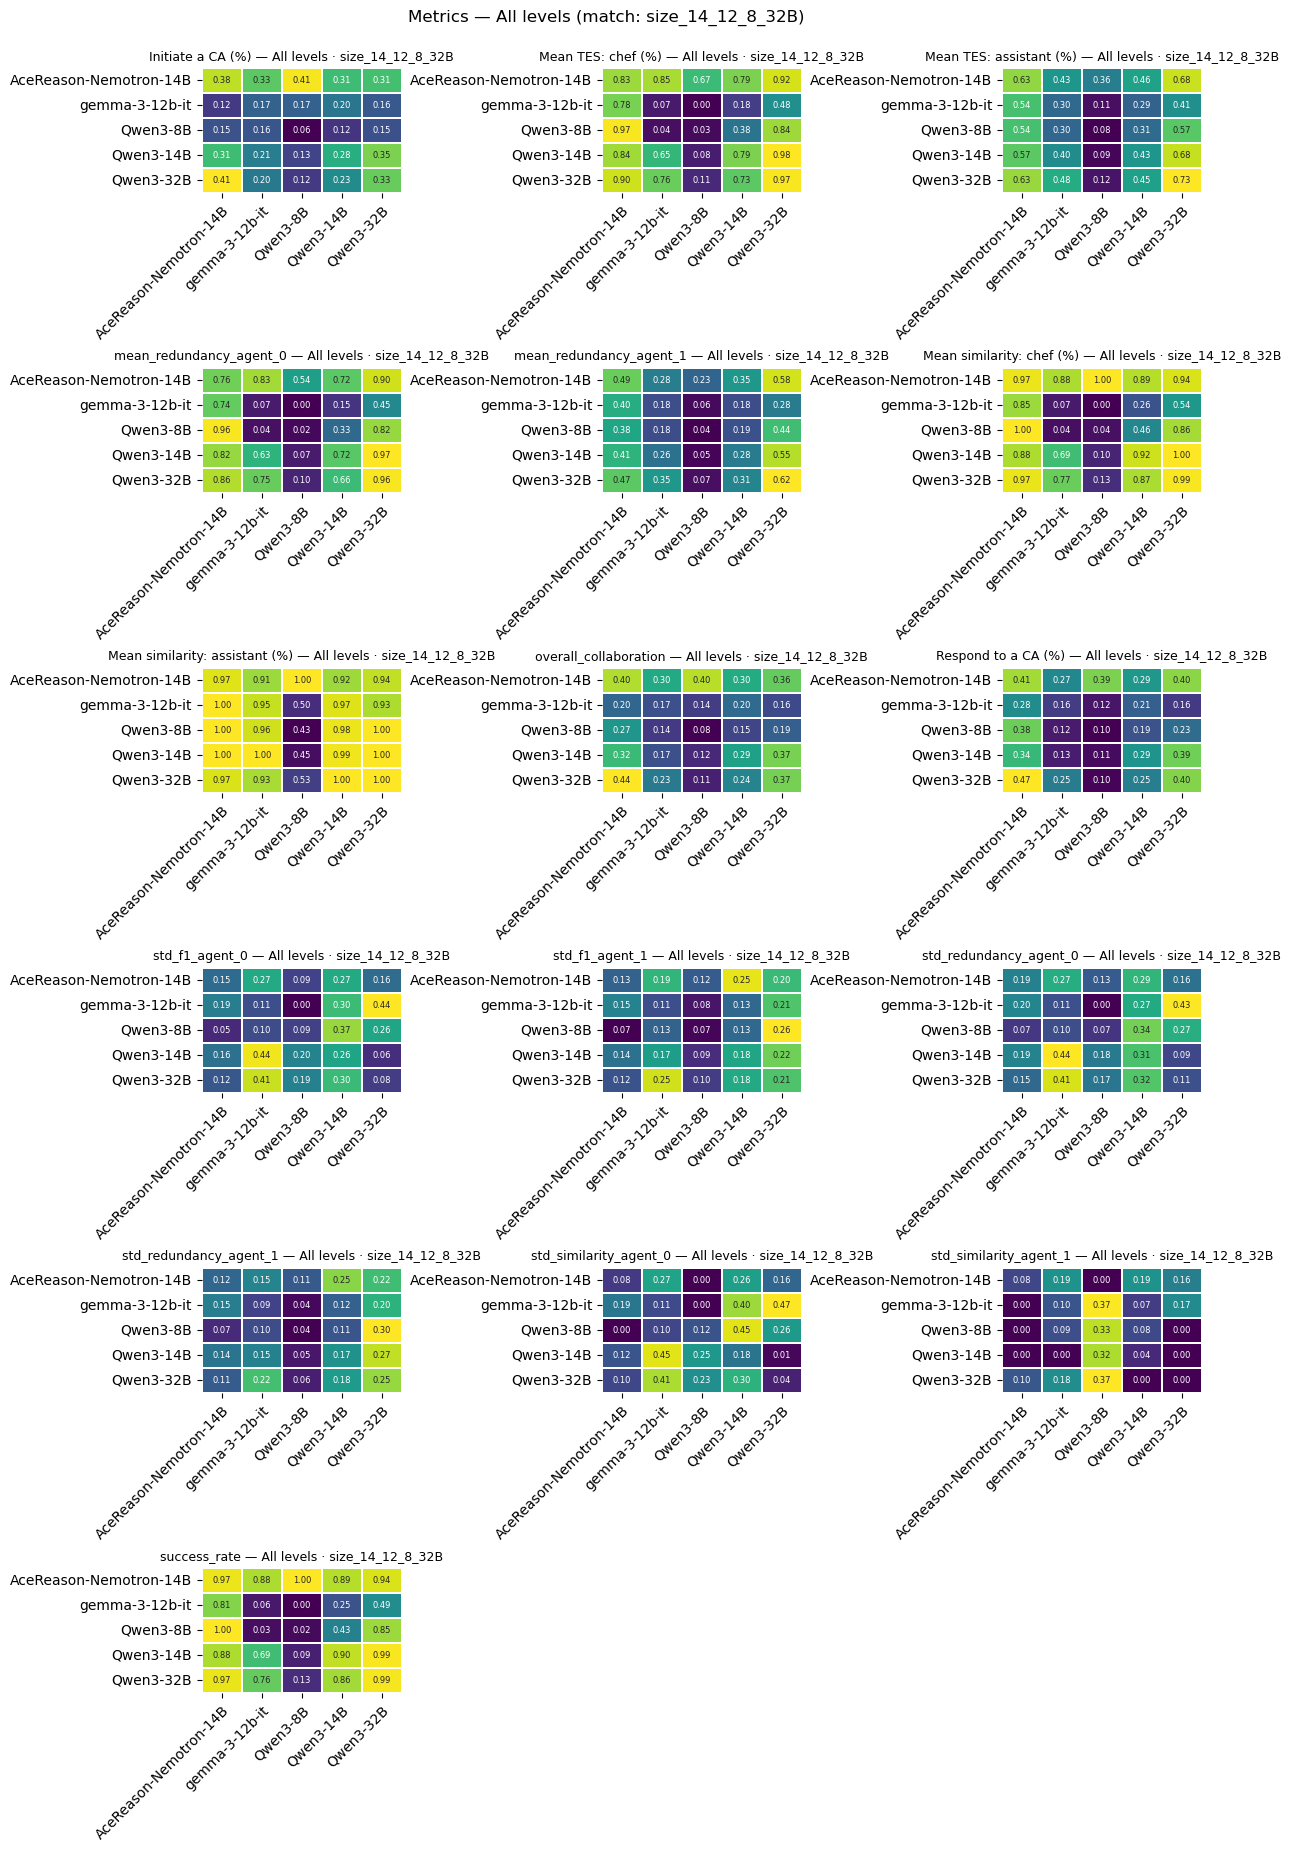

In [4]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Generate annotated heat-maps for every numeric metric in the input CSV.
Adds level-aware reporting and parameter-size "match group" sub-matrices.

Fixes (2025-08-19)
  • Robust size parsing for labels like "Gemma-2-27B-it" (search size anywhere, not only after the last dash)
  • Broader Unicode normalization for hyphen-like characters and zero-width/nbsp characters
  • Option to skip trivial 1×1 matrices (default: skip)

Features
  • Per-level heat-maps (each level separately)
  • Optional "all levels" aggregate, with configurable aggregation function
  • Parameter-size match groups (e.g., 4B only; 12B+14B; 8/12/14/32B)
  • Identical styling for inline grids and saved PNGs
  • Folder structure: heatmaps/<level_slug>/[match_<group_slug>]/...

Updated: 2025-08-19 — parameter-size match groups
  • ENABLE_MATCH_GROUPS / ONLY_MATCH_GROUPS
  • MATCH_GROUPS with SIZE_TOLERANCE_B window

Retains earlier changes (2025-08-11)
  • LEVEL_MODE: "each" | "all" | "each_and_all"
  • LEVELS_TO_INCLUDE: None (auto) or explicit list
  • Aggregation function for "all levels" is configurable (default: mean)
  • Folder structure: heatmaps/<level_slug>/...

Retains earlier changes (2025-07-09)
  • Centralised heat-map kwargs for PNG/inline parity
  • Suppressed colour-bars; compact 4×3 panels
  • Unicode U+2011 → ASCII "-" normalization to avoid glyph warnings (extended now)
  • Identical titles for PNG and inline
"""

from __future__ import annotations

import math
import re
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ───────────────────────────────────────────────────────────────
# 0. User-configurable labels  (edit below as needed)
# ───────────────────────────────────────────────────────────────
# Pretty names for models that will appear on axes ticks.
# Keys must match raw entries found in agent0_model / agent1_model
model_labels: dict[str, str] = {
    "Qwen2.5-14B-Instruct": "Qwen2.5-14B",
    "Qwen2.5-32B-Instruct": "Qwen2.5-32B",
    "Qwen2.5-7B-Instruct" : "Qwen2.5-07B",
    "Mistral-7B-Instruct-v0.1": "Mistral-07B",
    "Meta-Llama-3-8B-Instruct": "Llama3-08B",
}

# Pretty names for metric labels and colour-bar.
metric_labels: dict[str, str] = {
    "mean_similarity_agent_0": "Mean similarity: chef (%)",
    "mean_similarity_agent_1": "Mean similarity: assistant (%)",
    "mean_f1_agent_0": "Mean TES: chef (%)",
    "mean_f1_agent_1": "Mean TES: assistant (%)",
    "initiate_collaboration": "Initiate a CA (%)",
    "respond_collaboration": "Respond to a CA (%)",
}

# Optional: human-friendly names for levels, e.g. {0: "Easy", 1: "Med", 2: "Hard"}
level_labels: dict = {}  # leave empty to use the raw level values

# Axis labels (set to blank to mirror inline view)
x_axis_label: str = ""
y_axis_label: str = ""
# Title template mirrors inline/PNG parity.
# Use {metric_label} and {level_label} tokens; for "all levels" we inject "All levels".
title_template: str = "{metric_label} — {level_label}"

# ───────────────────────────────────────────────────────────────
# 0-bis. Centralised heat-map styling — single source of truth
# ───────────────────────────────────────────────────────────────
HEATMAP_KWARGS: dict = dict(
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    cmap="viridis",
    linewidths=0.25,
    linecolor="white",
    cbar=False,
)

# ───────────────────────────────────────────────────────────────
# 0-ter. Level reporting controls
# ───────────────────────────────────────────────────────────────
# Choose: "each" (per-level only), "all" (aggregate only), "each_and_all" (both)
LEVEL_MODE: str = "each_and_all"

# Explicit subset of levels to include, or None to auto-discover
LEVELS_TO_INCLUDE: Optional[Iterable] = None

# Aggregation function for "all levels"
AGG_FUN = "mean"  # "mean", "median", "max", "min", or any pandas reducer name

# Composite grid layout (inline)
N_COLS_COMPOSITE: int = 3

# ───────────────────────────────────────────────────────────────
# 0-quater. Match/group rendering by parameter size (in billions)
# ───────────────────────────────────────────────────────────────
ENABLE_MATCH_GROUPS: bool = True     # also render match groups
ONLY_MATCH_GROUPS: bool = False      # if True, skip the unfiltered matrices
SIZE_TOLERANCE_B: float = 0.4        # ±0.4B window for matching sizes

# Define the size buckets of interest (raw numbers in billions).
# Keys become folder names and title suffixes.
MATCH_GROUPS: dict[str, dict] = {
    "size_4B": {"sizes_b": [4]},
    "size_14B_12B": {"sizes_b": [14, 12]},
    "size_14_12_8_32B": {"sizes_b": [14, 12, 8, 32]},
    # Example Gemma buckets you might want:
    # "size_2_9_27B": {"sizes_b": [2, 9, 27]},
}

# Skip trivial 1×1 matrices (exactly one row × one column)
SKIP_TRIVIAL_1x1: bool = True

# ───────────────────────────────────────────────────────────────
# 1. Load and pre-process
# ───────────────────────────────────────────────────────────────
# IMPORTANT: point this to your uploaded CSV file
csv_path = "converted_data_cross-play-data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Ensure we have agent0_model / agent1_model:
if {"agent0_model", "agent1_model"}.issubset(df.columns):
    pass
elif "model" in df.columns:
    # Split the composite model column → agent0_model / agent1_model
    # Assumes "model" looks like "..._<agent0>_VS_<agent1>_..."
    parts = df["model"].astype(str).str.split("_", expand=True)
    try:
        df["agent0_model"] = parts[1]
        df["agent1_model"] = parts[3]
    except Exception:
        # Regex fallback: capture tokens around '_VS_' (more permissive trailing/leading)
        m = df["model"].astype(str).str.extract(r"(?:^|_) (?P<a0>[^_]+) _VS_ (?P<a1>[^_]+) (?:_|$)", expand=True, flags=re.X)
        if m.isna().any().any():
            raise ValueError(
                "Could not parse agent models from 'model' column. "
                "Expected pattern like '..._<agent0>_VS_<agent1>_...'."
            )
        df["agent0_model"] = m["a0"]
        df["agent1_model"] = m["a1"]
else:
    raise ValueError(
        "Input must contain either 'agent0_model' and 'agent1_model' columns, "
        "or a composite 'model' column that encodes them."
    )

# Unicode normalization helpers
_HYPHEN_CLASS = r"\u2010\u2011\u2012\u2013\u2014\u2212"  # hyphen, nb-hyphen, figure, en, em, minus
_ZW_CLASS = r"\u200b\u200c\u200d\ufeff"  # zero-widths/BOM
_NBSP_CLASS = r"\u00a0\u202f"  # nbsp/narrow-nbsp

def _normalize_label(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    # Replace any hyphen-like char with ASCII '-'
    s = re.sub(f"[{_HYPHEN_CLASS}]", "-", s)
    # Remove zero-width chars
    s = re.sub(f"[{_ZW_CLASS}]", "", s)
    # Replace non-breaking spaces with regular spaces
    s = re.sub(f"[{_NBSP_CLASS}]", " ", s)
    # Collapse spaces and trim
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Normalize model labels mapping keys once
model_labels = {_normalize_label(k): v for k, v in model_labels.items()}

# Replace hyphen-like chars and strip in the data
for col in ("agent0_model", "agent1_model"):
    df[col] = (
        df[col]
        .astype(str)
        .apply(_normalize_label)
    )

# If 'level' column is missing, create a single dummy level to keep pipeline uniform.
if "level" not in df.columns:
    print("[INFO] 'level' column not found; creating a single dummy level=0.")
    df["level"] = 0

# Identify numeric metric columns (drop clearly non-metric timing columns if present)
drop_non_metrics = [c for c in ["level", "steps", "time_avg", "time_var"] if c in df.columns]
numeric_cols = (
    df.select_dtypes(include="number")
      .columns.difference(drop_non_metrics)
      .tolist()
)
if not numeric_cols:
    raise ValueError("No numeric metric columns detected after exclusions.")

# Decide which levels we will include
if LEVELS_TO_INCLUDE is None:
    # Use the order of appearance (stable) for consistent panel ordering
    levels_in_data = list(pd.unique(df["level"]))
else:
    levels_in_data = list(LEVELS_TO_INCLUDE)

# Helper to pretty-print level values
def _level_name(val):
    if val == "__ALL__":
        return "All levels"
    return level_labels.get(val, str(val))

# ───────────────────────────────────────────────────────────────
# 2. Group once at the most granular level we care about
#    Mean over duplicate rows within (agent0, agent1, level)
# ───────────────────────────────────────────────────────────────
group_cols = ["agent0_model", "agent1_model", "level"]
df_mean = (
    df.groupby(group_cols, dropna=False)[numeric_cols]
      .mean()
      .reset_index()
)

# Build a list of "reporting scopes": each level, plus optionally an "__ALL__" aggregate
report_scopes = []
if LEVEL_MODE in ("each", "each_and_all"):
    report_scopes.extend(levels_in_data)
if LEVEL_MODE in ("all", "each_and_all"):
    report_scopes.append("__ALL__")

# ───────────────────────────────────────────────────────────────
# 3. Rendering utilities
# ───────────────────────────────────────────────────────────────

# If you mix families (e.g., Qwen3, Llama3, Gemma-2), set this True to sort "within family"
ORDER_WITHIN_FAMILY = True

_SCALE = {"K": 1e-3, "M": 1e-6, "B": 1.0, "T": 1e3}

_SIZE_RE = re.compile(r"(\d+(?:\.\d+)?)\s*([KMBT])\b", flags=re.I)

def _find_size_token(label: str) -> Optional[tuple[float, str]]:
    """Return (size_in_billions, matched_text) if any size token exists anywhere in the label.
    Chooses the *rightmost* match to prefer the actual parameter size (e.g., 'Gemma-2-27B-it').
    """
    s = _normalize_label(str(label))
    matches = list(_SIZE_RE.finditer(s))
    if not matches:
        return None
    m = matches[-1]  # choose rightmost occurrence
    num = float(m.group(1))
    unit = m.group(2).upper()
    size_b = num * _SCALE.get(unit, 1.0)
    return size_b, m.group(0)

def _size_sort_key(label: str):
    """
    Sorting key: primarily by family, then by parsed size in billions.
    Falls back to casefold for stability when unparseable.
    """
    s = _normalize_label(str(label))
    # Family = everything up to the size token (if present); otherwise, up to last '-'
    size_info = _find_size_token(s)
    if size_info is not None:
        size_b, token = size_info
        fam = s.split(token, 1)[0]
    else:
        size_b = float("inf")
        fam = s.rsplit("-", 1)[0] if "-" in s else s

    if ORDER_WITHIN_FAMILY:
        return (fam.casefold(), size_b, s.casefold())
    else:
        return (size_b, fam.casefold(), s.casefold())

def _parse_size_b(label: str) -> float:
    """
    Extract numeric size in billions from anywhere in the model label (e.g., 'Gemma-2-27B-it').
    Returns float('nan') if unparseable.
    """
    res = _find_size_token(label)
    return res[0] if res is not None else float("nan")

def _filter_names_by_sizes(names: Iterable[str], sizes_b: Iterable[float], tol_b: float) -> list[str]:
    """
    Keep names whose parsed size is within tol_b of any target size.
    Preserve the original order.
    """
    targets = [float(x) for x in sizes_b]
    keep_set = set()
    for n in names:
        sb = _parse_size_b(n)
        if math.isnan(sb):
            continue
        if any(abs(sb - t) <= tol_b for t in targets):
            keep_set.add(n)
    return [x for x in names if x in keep_set]

def _slug(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "-", str(s).lower()).strip("-")

def _pivot_for_scope(metric: str, scope):
    """
    Return a pivot (rows=agent0, cols=agent1) for a given metric and scope (level or "__ALL__").
    Applies model label prettification and sorts axes.
    """
    if scope == "__ALL__":
        # Aggregate across levels first
        agg = (
            df_mean.groupby(["agent0_model", "agent1_model"], dropna=False)[metric]
                  .agg(AGG_FUN)
                  .reset_index()
        )
    else:
        # Filter for the specific level
        agg = df_mean[df_mean["level"] == scope][["agent0_model", "agent1_model", metric]]

    pivot = (
        agg.groupby(["agent0_model", "agent1_model"])[metric]
           .mean()
           .unstack(fill_value=np.nan)
    )

    # Apply pretty labels (post grouping to avoid collisions)
    pivot = pivot.rename(index=model_labels, columns=model_labels)

    # Sort axes by numeric model size (then by family for ties if enabled)
    row_order = sorted(pivot.index, key=_size_sort_key)
    col_order = sorted(pivot.columns, key=_size_sort_key)
    pivot = pivot.reindex(index=row_order, columns=col_order)
    return pivot

def _save_and_collect(scope, out_root: Path, *,
                      subgroup_name: Optional[str] = None,
                      pivot_filter=None):
    """
    Save individual PNGs for a scope (and optional subgroup) to heatmaps/<level>/<subgroup>/...
    Returns [(metric_label, pivot), ...] and the output directory.
    """
    level_slug = "all_levels" if scope == "__ALL__" else f"level_{_level_name(scope)}".replace(" ", "_")
    base_dir = out_root / level_slug
    out_dir = base_dir if not subgroup_name else (base_dir / f"match_{_slug(subgroup_name)}")
    out_dir.mkdir(parents=True, exist_ok=True)

    collected: list[tuple[str, pd.DataFrame]] = []
    for metric in numeric_cols:
        pivot = _pivot_for_scope(metric, scope)

        # Apply optional filtering (e.g., by size group)
        if pivot_filter is not None:
            pivot = pivot_filter(pivot)

        # Skip empty or trivial matrices gracefully
        if pivot.shape[0] == 0 or pivot.shape[1] == 0:
            print(f"[INFO] Skipping empty matrix for metric='{metric}' scope='{_level_name(scope)}' "
                  f"subgroup='{subgroup_name}'")
            continue
        if SKIP_TRIVIAL_1x1 and pivot.shape == (1, 1):
            print(f"[INFO] Skipping trivial 1x1 matrix for metric='{metric}' scope='{_level_name(scope)}' "
                  f"subgroup='{subgroup_name}' labels=({pivot.index[0]} vs {pivot.columns[0]})")
            continue

        metric_label = metric_labels.get(metric, metric)
        collected.append((metric_label, pivot))

        fig, ax = plt.subplots(figsize=(4, 3))
        sns.heatmap(pivot, **HEATMAP_KWARGS, ax=ax)

        level_str = _level_name(scope)
        if subgroup_name:
            level_str = f"{level_str} · {subgroup_name}"
        title = title_template.format(metric_label=metric_label, level_label=level_str)

        ax.set_title(title, pad=8)
        ax.set_xlabel(x_axis_label)
        ax.set_ylabel(y_axis_label)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        fig.tight_layout()
        suffix = f"_{_slug(subgroup_name)}" if subgroup_name else ""
        outfile = out_dir / f"heatmap_{metric}{suffix}.png"
        fig.savefig(outfile, dpi=300)
        plt.close(fig)
        print(f"Saved {outfile}")
    return collected, out_dir

def _composite_inline(collected: list[tuple[str, pd.DataFrame]], scope, subgroup_name: Optional[str] = None):
    """
    Show a compact inline grid for a given scope and optional subgroup.
    """
    n = len(collected)
    if n == 0:
        return
    ncols = max(1, N_COLS_COMPOSITE)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4, nrows * 3),
        squeeze=False,
        constrained_layout=True,
    )

    for idx, (metric_label, pivot) in enumerate(collected):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        sns.heatmap(pivot, **HEATMAP_KWARGS, ax=ax)

        level_str = _level_name(scope)
        if subgroup_name:
            level_str = f"{level_str} · {subgroup_name}"
        inline_title = title_template.format(metric_label=metric_label, level_label=level_str)

        ax.set_title(inline_title, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Hide any unused axes
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    sup = f"Metrics — {_level_name(scope)}"
    if subgroup_name:
        sup += f" (match: {subgroup_name})"
    fig.suptitle(sup, y=1.02, fontsize=12)
    plt.show()

# ───────────────────────────────────────────────────────────────
# 4. Run: save PNGs and show inline grids for each requested scope
# ───────────────────────────────────────────────────────────────

def _make_pivot_filter_for_sizes(sizes_b: list[float], tol_b: float):
    """
    Returns a function that, given a pivot DataFrame, filters rows/cols to the
    names matching any of the provided sizes within ±tol_b (in billions).
    """
    def _pf(piv: pd.DataFrame) -> pd.DataFrame:
        rows = _filter_names_by_sizes(list(piv.index), sizes_b, tol_b)
        cols = _filter_names_by_sizes(list(piv.columns), sizes_b, tol_b)
        return piv.loc[rows, cols]
    return _pf

def main():
    out_root = Path("heatmaps")
    out_root.mkdir(exist_ok=True)

    for scope in report_scopes:
        # Unfiltered matrices (unless ONLY_MATCH_GROUPS is set)
        if not ONLY_MATCH_GROUPS:
            try:
                collected, _ = _save_and_collect(scope, out_root)
                _composite_inline(collected, scope)
            except Exception as e:
                print(f"[WARN] Skipped inline view (all sizes) for scope={_level_name(scope)} due to: {e}")

        # Size-match groups
        if ENABLE_MATCH_GROUPS and MATCH_GROUPS:
            for group_name, spec in MATCH_GROUPS.items():
                sizes = list(map(float, spec.get("sizes_b", [])))
                pivot_filter = _make_pivot_filter_for_sizes(sizes, SIZE_TOLERANCE_B)
                try:
                    collected, _ = _save_and_collect(scope, out_root,
                                                     subgroup_name=group_name,
                                                     pivot_filter=pivot_filter)
                    _composite_inline(collected, scope, subgroup_name=group_name)
                except Exception as e:
                    print(f"[WARN] Skipped inline view for scope={_level_name(scope)} "
                          f"group='{group_name}' due to: {e}")

if __name__ == "__main__":
    main()
